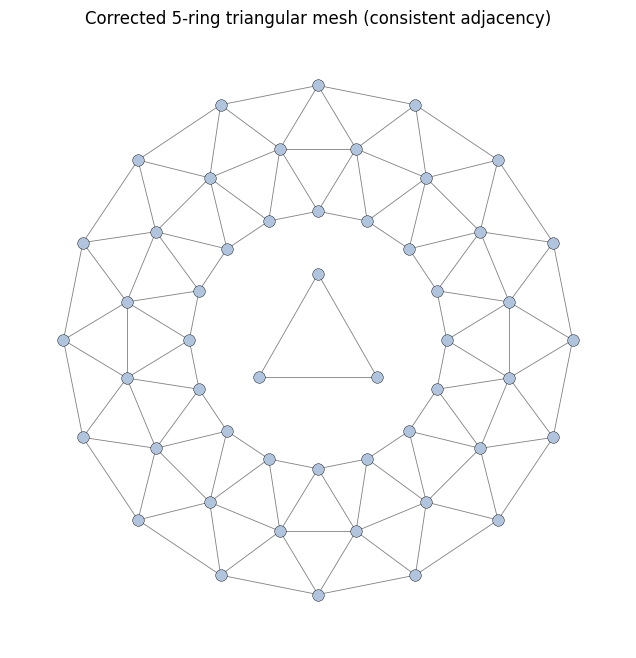

In [188]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def build_fixed_ring_mesh(n=16, n_rings=3, r0=1.75, dr=1.0, with_triangle=True):
    """
    Build a polar triangular lattice with alternating angular offsets.
    Ensures consistent adjacency (no drifting).
    """
    G = nx.Graph()
    pos = {}

    base_angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    half_step = (np.pi*2)/(2*n)

    # Create nodes with alternating offset
    radius = r0
    for r in range(n_rings):
        angs = base_angles + (half_step if r % 2 == 1 else 0)
        for i, theta in enumerate(angs):
            node = (r, i)
            pos[node] = (radius*np.cos(theta), radius*np.sin(theta))
            G.add_node(node, pos=pos[node])
        dr = dr * 0.9
        radius = radius + dr

    # Connect within rings (cycles)
    for r in range(n_rings):
        for i in range(n):
            G.add_edge((r, i), (r, (i+1) % n))

    # Connect across rings with zig-zag consistency
    for r in range(n_rings-1):
        for i in range(n):
            if r % 2 == 0:  # even ring (no offset)
                G.add_edge((r, i), (r+1, i))
                G.add_edge((r, i), (r+1, (i-1) % n))
            else:  # odd ring (offset)
                G.add_edge((r, i), (r+1, i))
                G.add_edge((r, i), (r+1, (i+1) % n))

    # Optional central triangle
    if with_triangle:
        tri_coords = np.array([[0.0, 0.9], [-0.8, -0.5], [0.8, -0.5]])
        t_ids = [("T", i) for i in range(3)]
        for tid, p in zip(t_ids, tri_coords):
            pos[tid] = (float(p[0]), float(p[1]))
            G.add_node(tid, pos=pos[tid])
        G.add_edges_from([(t_ids[0], t_ids[1]), (t_ids[1], t_ids[2]), (t_ids[2], t_ids[0])])

    return G, pos

# Build corrected mesh
G_corr, pos_corr = build_fixed_ring_mesh(with_triangle=True)

# Plot corrected adjacency (no GP yet)
plt.figure(figsize=(8,8))
nx.draw_networkx_edges(G_corr, pos_corr, alpha=0.5, width=0.6)
nx.draw_networkx_nodes(G_corr, pos_corr, node_size=70, node_color="lightsteelblue", edgecolors="k", linewidths=0.3)
plt.gca().set_aspect("equal")
plt.axis("off")
plt.title("Corrected 5-ring triangular mesh (consistent adjacency)")
plt.show()


In [205]:
np.random.seed(5)

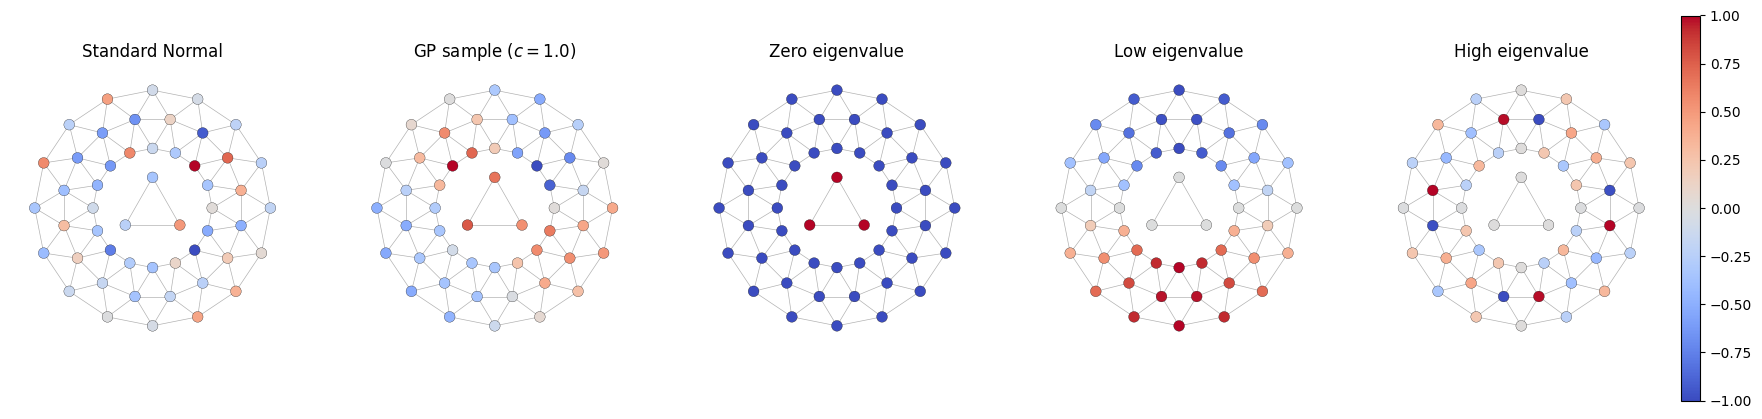

In [206]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

G_corr, pos_corr = build_fixed_ring_mesh(n_rings=3)
nodes_corr = list(G_corr.nodes())

# --- 2) Laplacian ---
L_corr = nx.laplacian_matrix(G_corr).astype(float).todense()
L_corr = np.array(L_corr)

# --- 3) Eigen-decomposition and GP samples ---
w, U = np.linalg.eigh(L_corr)

def get_eigenvector(idx):
    v = U[:, idx]
    v = v / np.max(np.abs(v))
    return v

tol = 1e-8
zero_idx = np.where(np.abs(w) < tol)[0]
low_idx = np.where((w > tol) & (w < 0.5))[0]
high_idx = np.where(w > np.percentile(w, 90))[0]

zero_vec = get_eigenvector(zero_idx[0]) if len(zero_idx) else get_eigenvector(0)
low_vec = get_eigenvector(low_idx[0]) if len(low_idx) else get_eigenvector(1)
high_vec = get_eigenvector(high_idx[0]) if len(high_idx) else get_eigenvector(-1)

z_std = np.random.randn(L_corr.shape[0])

c = 1.0
sqrt_cov_eigs_gp = np.sqrt(np.exp(-c * w))
z = np.random.randn(L_corr.shape[0])
gp_sample = U @ (sqrt_cov_eigs_gp * (U.T @ z))

# --- 4) Visualization ---
fig, axes = plt.subplots(1, 5, figsize=(22,5))
datasets = {
    "Standard Normal": z_std,
    r"GP sample ($c=1.0$)": gp_sample,
    "Zero eigenvalue": zero_vec,
    "Low eigenvalue": low_vec,
    "High eigenvalue": high_vec
}

for ax, (title, values) in zip(axes, datasets.items()):
    vals = {node: values[i] for i, node in enumerate(nodes_corr)}
    colors = [vals[node] for node in nodes_corr]
    nx.draw_networkx_edges(G_corr, pos_corr, ax=ax, alpha=0.3, width=0.5)
    sc = nx.draw_networkx_nodes(G_corr, pos_corr, ax=ax,
                                node_color=colors, cmap="coolwarm",
                                node_size=60, linewidths=0.2, edgecolors="k")
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

plt.colorbar(sc, ax=axes, orientation="vertical", fraction=0.02, pad=0.01)
plt.show()


In [362]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Polygon

G_corr, pos_corr = build_fixed_ring_mesh(n=16, n_rings=3)

# --- 2) Oriented structures (edges, faces, boundary matrices) ---
def build_oriented_structures(G, pos):
    nodes = list(G.nodes())
    node_idx = {n:i for i,n in enumerate(nodes)}

    # Oriented edges: (u,v) with idx[u] < idx[v]
    edges = []
    for u,v in G.edges():
        if node_idx[u] < node_idx[v]:
            edges.append((u,v))
        else:
            edges.append((v,u))
    edges = list(dict.fromkeys(edges))
    edge_idx = {e:i for i,e in enumerate(edges)}

    # Triangles
    cliques = [c for c in nx.enumerate_all_cliques(G) if len(c) == 3]
    faces = []
    for a,b,c in cliques:
        tri = sorted([a,b,c], key=lambda x: node_idx[x])
        faces.append(tuple(tri))
    faces = list(dict.fromkeys(faces))
    face_idx = {f:i for i,f in enumerate(faces)}

    # B1
    nV, m, F = len(nodes), len(edges), len(faces)
    B1 = np.zeros((nV,m))
    for (u,v) in edges:
        iu, iv = node_idx[u], node_idx[v]
        B1[iu, edge_idx[(u,v)]] = +1.0
        B1[iv, edge_idx[(u,v)]] = -1.0

    # B2
    B2 = np.zeros((m,F))
    for f in faces:
        a,b,c = f
        bdry = [(a,b),(b,c),(c,a)]
        for (p,q) in bdry:
            if node_idx[p] < node_idx[q]:
                e = (p,q); sign = +1.0
            else:
                e = (q,p); sign = -1.0
            if e in edge_idx:
                B2[edge_idx[e], face_idx[f]] = sign

    return nodes, edges, faces, B1, B2

nodes, edges, faces, B1, B2 = build_oriented_structures(G_corr, pos_corr)

# --- 3) Hodge L1 and eigen-decomposition ---
L1 = B1.T @ B1 + B2 @ B2.T
w1, U1 = np.linalg.eigh(L1)

def norm_vec(v): return v/(np.max(np.abs(v))+1e-12)

tol = 1e-8
zero_ids = np.where(np.abs(w1) < tol)[0]
low_ids = np.where((w1 >= tol) & (w1 < np.percentile(w1, 20)))[0]
high_ids = np.where(w1 > np.percentile(w1, 95))[0]

v_zero = norm_vec(U1[:, zero_ids[0]]) if len(zero_ids) else norm_vec(U1[:,0])
v_low  = norm_vec(U1[:, low_ids[0]])  if len(low_ids)  else norm_vec(U1[:,1])
v_high = norm_vec(U1[:, high_ids[0]]) if len(high_ids) else norm_vec(U1[:,-1])


# 21

In [363]:
np.random.seed(21)
c = 2.0

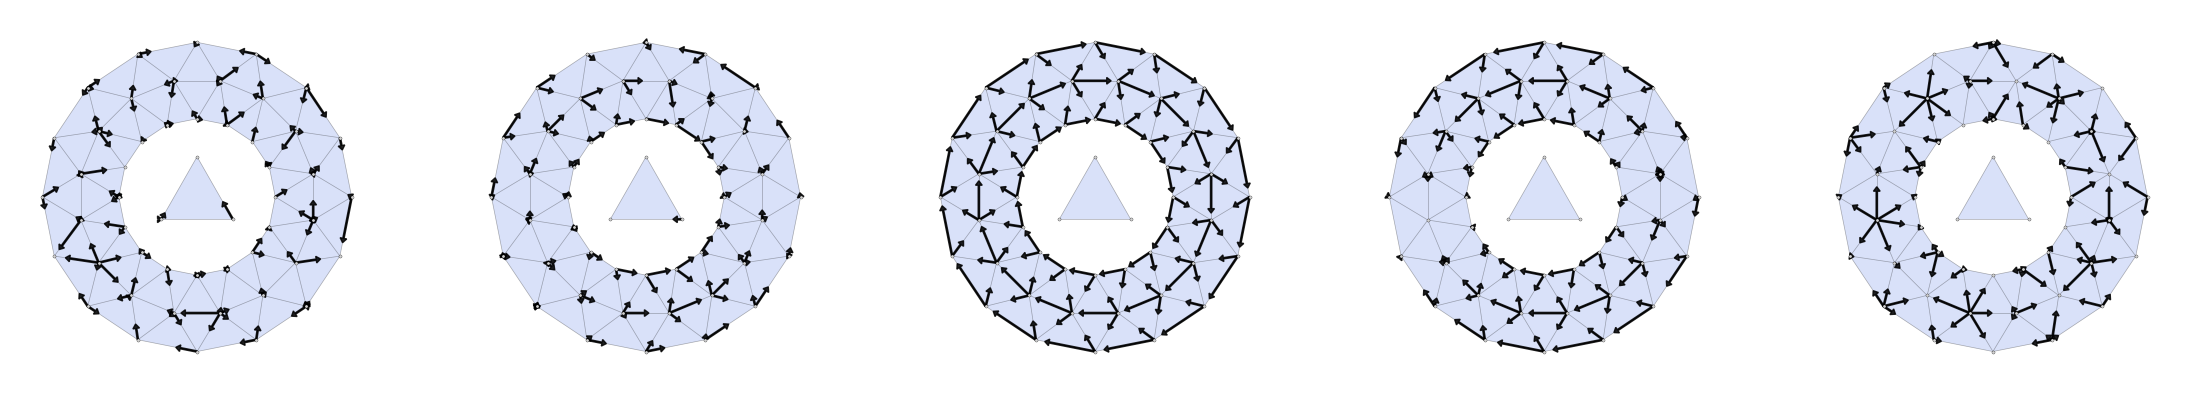

In [364]:


# --- Random samples ---
z_std = np.random.randn(L1.shape[0])

sqrt_cov_eigs_gp = np.sqrt(np.exp(-c * w1))
z = np.random.randn(L1.shape[0])
gp_sample = U1 @ (sqrt_cov_eigs_gp * (U1.T @ z))

# --- Plotting function ---
def plot_edge_arrows_with_faces(values, title, ax, max_scale=0.85, thresh=0.02):
    # Fill all faces
    for f in faces:
        coords = [pos_corr[n] for n in f]
        poly = Polygon(coords, closed=True, facecolor="royalblue", alpha=0.2, edgecolor=None)
        ax.add_patch(poly)

    # Faint edges in the background
    nx.draw_networkx_edges(G_corr, pos_corr, ax=ax, width=0.5, alpha=0.3, edge_color="k")

    vmax = np.max(np.abs(values)) + 1e-12
    for k,(u,v) in enumerate(edges):
        mag = values[k]
        if abs(mag) < thresh:
            continue
        x0,y0 = pos_corr[u]; x1,y1 = pos_corr[v]
        dx, dy = x1-x0, y1-y0
        scale = max_scale * (abs(mag) / vmax)
        if mag >= 0:
            dxs, dys = scale*dx, scale*dy
            startx, starty = x0, y0
        else:
            dxs, dys = -scale*dx, -scale*dy
            startx, starty = x1, y1
        ax.arrow(startx, starty, dxs, dys,
                 head_width=0.15, head_length=0.1,
                 fc="k", ec="k", alpha=0.85, width=0.03,
                 length_includes_head=True)

    nx.draw_networkx_nodes(G_corr, pos_corr, ax=ax, node_size=5,
                           node_color="lightgray", edgecolors="k", linewidths=0.2)

    ax.set_aspect("equal"); ax.axis("off")

# --- 5-panel figure ---
fig, axes = plt.subplots(1,5,figsize=(28,6))

datasets = {
    "Standard Normal": z_std,
    "GP sample": gp_sample,
    "Zero eigenvalue": v_zero,
    "Low eigenvalue": v_low,
    "High eigenvalue": v_high
}

for ax, (title, values) in zip(axes, datasets.items()):
    if title == "GP sample":
        plot_edge_arrows_with_faces(values, title, ax, max_scale=0.95)
    else:
        plot_edge_arrows_with_faces(values, title, ax)

plt.show()


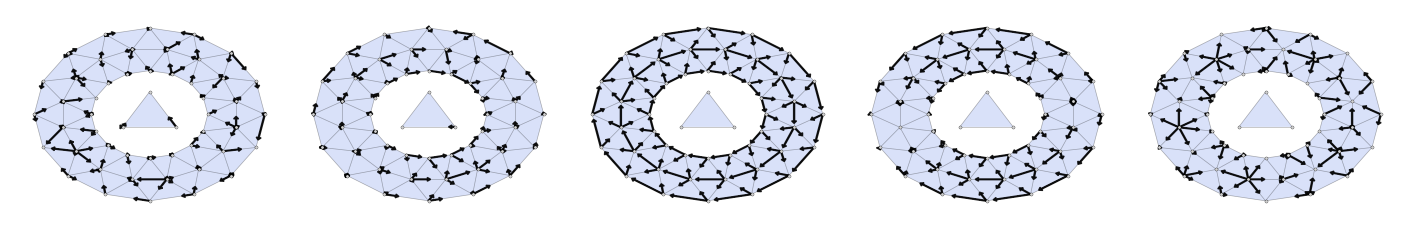

In [370]:
# --- 5-panel figure (squished + tighter) ---
fig, axes = plt.subplots(1,5,figsize=(18,3))  # narrower height, smaller figure

datasets = {
    "Standard Normal": z_std,
    "GP sample": gp_sample,
    "Zero eigenvalue": v_zero,
    "Low eigenvalue": v_low,
    "High eigenvalue": v_high
}

for ax, (title, values) in zip(axes, datasets.items()):
    if title == "GP sample":
        plot_edge_arrows_with_faces(values, title, ax, max_scale=0.95)
    else:
        plot_edge_arrows_with_faces(values, title, ax)
    ax.set_aspect(0.75)   # < 1 squishes vertically, > 1 stretches vertically

plt.subplots_adjust(wspace=0.0)  # shrink horizontal gaps
plt.show()


In [401]:
# Set retina backend
%config InlineBackend.figure_format='retina'

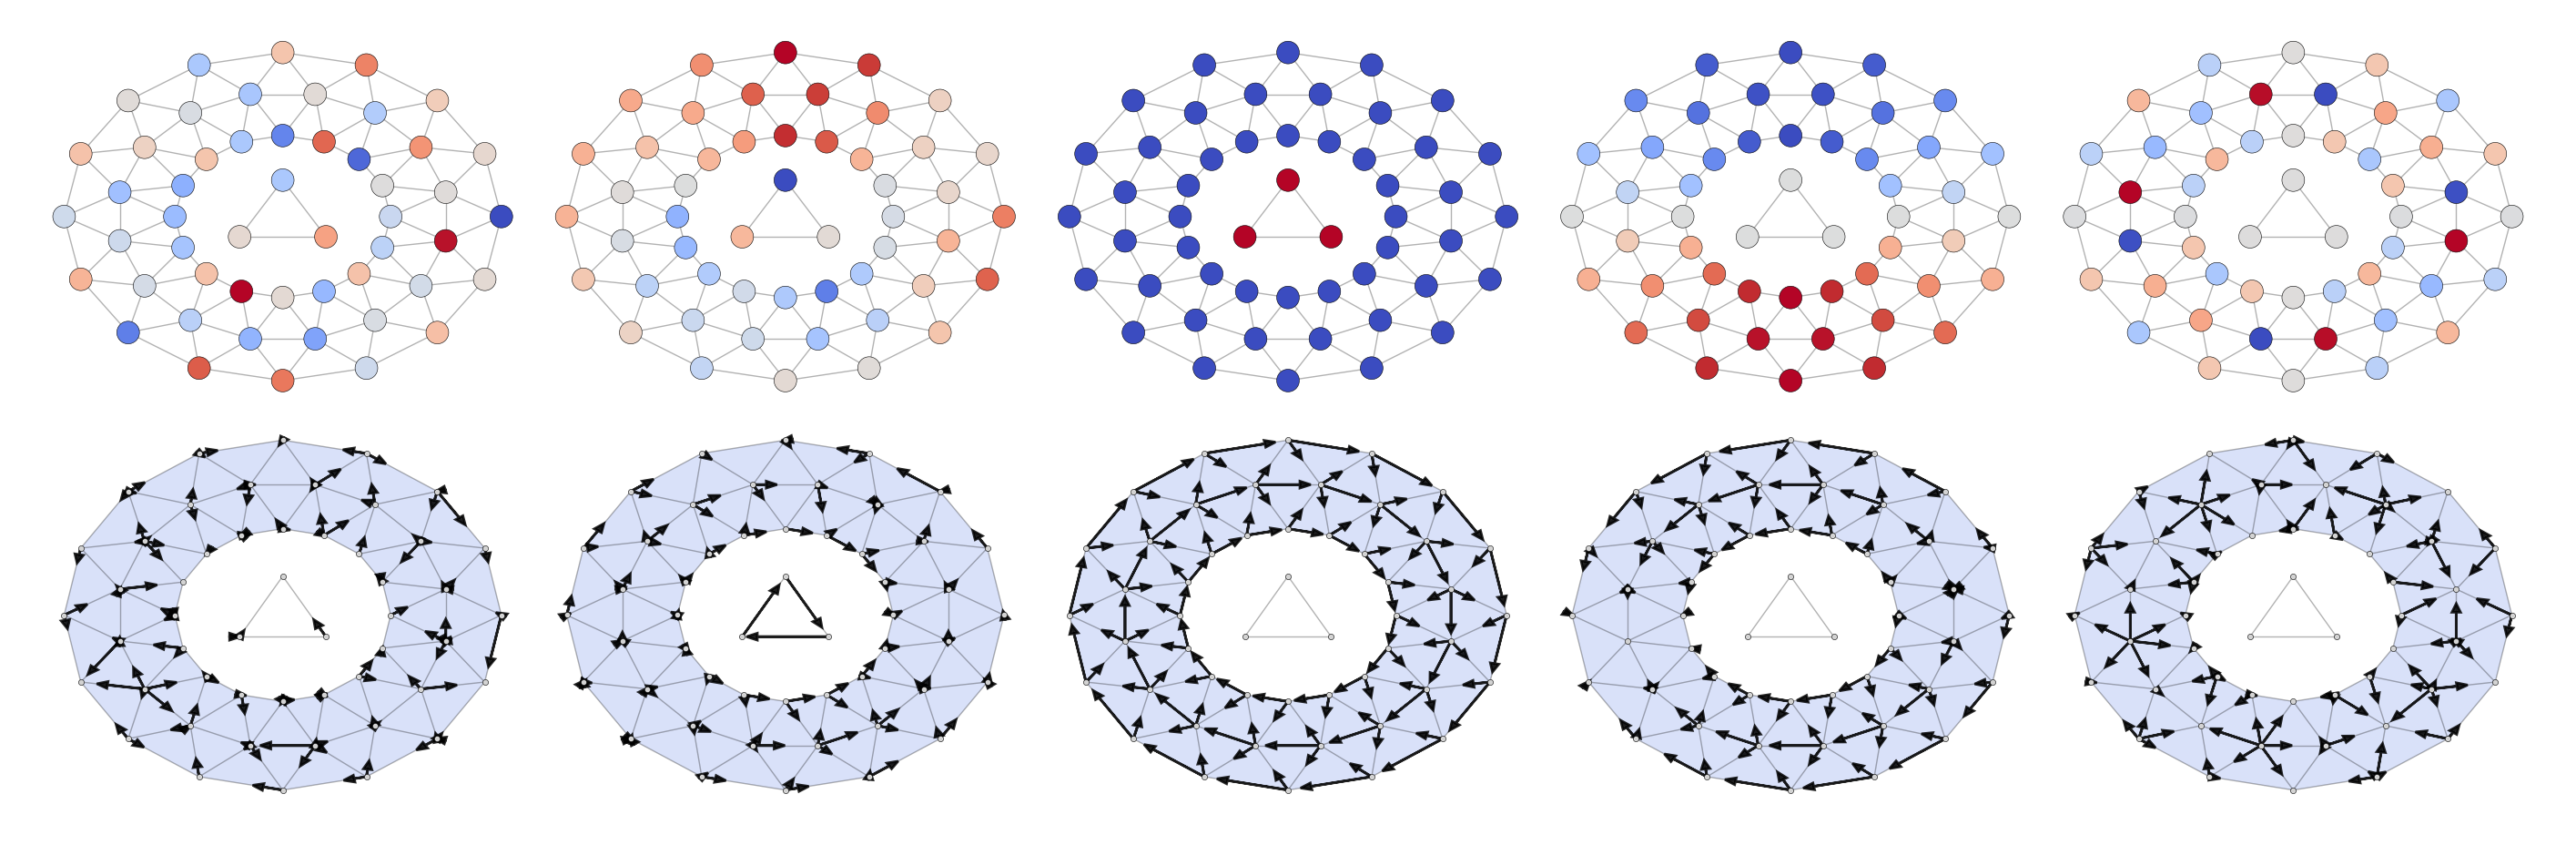

In [408]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Polygon

# --- 1) Build corrected mesh ---
def build_fixed_ring_mesh(n=16, n_rings=3, r0=0.5, dr=0.3, with_triangle=True):
    G = nx.Graph()
    pos = {}
    base_angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    half_step = (np.pi*2)/(2*n)
    radius = r0
    for r in range(n_rings):
        angs = base_angles + (half_step if r % 2 == 1 else 0)
        for i, theta in enumerate(angs):
            node = (r, i)
            pos[node] = (radius*np.cos(theta), radius*np.sin(theta))
            G.add_node(node, pos=pos[node])
        dr = dr * 0.9
        radius = radius + dr
    for r in range(n_rings):
        for i in range(n):
            G.add_edge((r, i), (r, (i+1) % n))
    for r in range(n_rings-1):
        for i in range(n):
            if r % 2 == 0:
                G.add_edge((r, i), (r+1, i))
                G.add_edge((r, i), (r+1, (i-1) % n))
            else:
                G.add_edge((r, i), (r+1, i))
                G.add_edge((r, i), (r+1, (i+1) % n))
    if with_triangle:
        tri_coords = np.array([[0.0, 0.9], [-0.8, -0.5], [0.8, -0.5]]) * 0.25
        t_ids = [("T", i) for i in range(3)]
        for tid, p in zip(t_ids, tri_coords):
            pos[tid] = (float(p[0]), float(p[1]))
            G.add_node(tid, pos=pos[tid])
        G.add_edges_from([(t_ids[0], t_ids[1]), (t_ids[1], t_ids[2]), (t_ids[2], t_ids[0])])
    return G, pos

G_corr, pos_corr = build_fixed_ring_mesh()
nodes_corr = list(G_corr.nodes())

# --- 2) Node Laplacian (L0) ---
L_corr = nx.laplacian_matrix(G_corr).astype(float).todense()
L_corr = np.array(L_corr)
w0, U0 = np.linalg.eigh(L_corr)

def get_eigenvector(U, idx):
    v = U[:, idx]
    v = v / np.max(np.abs(v))
    return v

tol = 1e-8
zero_idx = np.where(np.abs(w0) < tol)[0]
low_idx  = np.where((w0 > tol) & (w0 < 0.5))[0]
high_idx = np.where(w0 > np.percentile(w0, 90))[0]

zero_vec_nodes = get_eigenvector(U0, zero_idx[0]) if len(zero_idx) else get_eigenvector(U0, 0)
low_vec_nodes  = get_eigenvector(U0, low_idx[0])  if len(low_idx)  else get_eigenvector(U0, 1)
high_vec_nodes = get_eigenvector(U0, high_idx[0]) if len(high_idx) else get_eigenvector(U0, -1)

np.random.seed(2)
z_std_nodes = np.random.randn(L_corr.shape[0])
c = 1.0
sqrt_cov_eigs_gp = np.sqrt(np.exp(-c * w0))
z = np.random.randn(L_corr.shape[0])
gp_sample_nodes = U0 @ (sqrt_cov_eigs_gp * (U0.T @ z))

# --- 3) Oriented structures for edges (for L1) ---
def build_oriented_structures(G, pos):
    nodes = list(G.nodes())
    node_idx = {n:i for i,n in enumerate(nodes)}
    edges = []
    for u,v in G.edges():
        if node_idx[u] < node_idx[v]:
            edges.append((u,v))
        else:
            edges.append((v,u))
    edges = list(dict.fromkeys(edges))
    edge_idx = {e:i for i,e in enumerate(edges)}
    cliques = [c for c in nx.enumerate_all_cliques(G) if len(c) == 3]
    faces = []
    for a,b,c in cliques:
        tri = sorted([a,b,c], key=lambda x: node_idx[x])
        # --- skip central triangle made only of "T" nodes ---
        if all(isinstance(v, tuple) and v[0] == "T" for v in tri):
            continue
        faces.append(tuple(tri))
    faces = list(dict.fromkeys(faces))
    face_idx = {f:i for i,f in enumerate(faces)}
    nV, m, F = len(nodes), len(edges), len(faces)
    B1 = np.zeros((nV,m))
    for (u,v) in edges:
        iu, iv = node_idx[u], node_idx[v]
        B1[iu, edge_idx[(u,v)]] = +1.0
        B1[iv, edge_idx[(u,v)]] = -1.0
    B2 = np.zeros((m,F))
    for f in faces:
        a,b,c = f
        bdry = [(a,b),(b,c),(c,a)]
        for (p,q) in bdry:
            if node_idx[p] < node_idx[q]:
                e = (p,q); sign = +1.0
            else:
                e = (q,p); sign = -1.0
            if e in edge_idx:
                B2[edge_idx[e], face_idx[f]] = sign
    return nodes, edges, faces, B1, B2

nodes, edges, faces, B1, B2 = build_oriented_structures(G_corr, pos_corr)

# --- 4) Hodge L1 ---
np.random.seed(21)
c = 2.0
L1 = B1.T @ B1 + B2 @ B2.T
w1, U1 = np.linalg.eigh(L1)

def norm_vec(v): return v/(np.max(np.abs(v))+1e-12)

zero_ids = np.where(np.abs(w1) < tol)[0]
low_ids  = np.where((w1 >= tol) & (w1 < np.percentile(w1, 20)))[0]
high_ids = np.where(w1 > np.percentile(w1, 95))[0]

v_zero = norm_vec(U1[:, zero_ids[0]]) if len(zero_ids) else norm_vec(U1[:,0])
v_low  = norm_vec(U1[:, low_ids[0]])  if len(low_ids)  else norm_vec(U1[:,1])
v_high = norm_vec(U1[:, high_ids[0]]) if len(high_ids) else norm_vec(U1[:,-1])

z_std = np.random.randn(L1.shape[0])
sqrt_cov_eigs_gp = np.sqrt(np.exp(-c * w1))
z = np.random.randn(L1.shape[0])
gp_sample = U1 @ (sqrt_cov_eigs_gp * (U1.T @ z))

# --- 5) Plotting ---
def plot_edge_arrows_with_faces(values, ax, max_scale=0.85, thresh=0.02):
    for f in faces:
        coords = [pos_corr[n] for n in f]
        poly = Polygon(coords, closed=True, facecolor="royalblue", alpha=0.2, edgecolor=None)
        ax.add_patch(poly)
    nx.draw_networkx_edges(G_corr, pos_corr, ax=ax, width=0.5, alpha=0.3, edge_color="k")
    vmax = np.max(np.abs(values)) + 1e-12
    for k,(u,v) in enumerate(edges):
        mag = values[k]
        if abs(mag) < thresh:
            continue
        x0,y0 = pos_corr[u]; x1,y1 = pos_corr[v]
        dx, dy = x1-x0, y1-y0
        scale = max_scale * (abs(mag) / vmax)
        if mag >= 0:
            dxs, dys = scale*dx, scale*dy
            startx, starty = x0, y0
        else:
            dxs, dys = -scale*dx, -scale*dy
            startx, starty = x1, y1
        ax.arrow(startx, starty, dxs, dys,
                 head_width=0.04, 
                 head_length=0.05,
                 fc="k", ec="k", alpha=0.85, 
                 length_includes_head=True)
    nx.draw_networkx_nodes(G_corr, pos_corr, ax=ax, node_size=5,
                           node_color="lightgray", edgecolors="k", linewidths=0.2)
    ax.set_aspect(0.8); ax.axis("off")

# --- 6) Final 2x5 figure ---
fig, axes = plt.subplots(2, 5, figsize=(18,6))

datasets_node = {
    "Standard Normal": z_std_nodes,
    "GP sample": gp_sample_nodes,
    "Zero eigenvalue": zero_vec_nodes,
    "Low eigenvalue": low_vec_nodes,
    "High eigenvalue": high_vec_nodes
}
for ax, (title, values) in zip(axes[0], datasets_node.items()):
    vals = {node: values[i] for i, node in enumerate(nodes_corr)}
    colors = [vals[node] for node in nodes_corr]
    nx.draw_networkx_edges(G_corr, pos_corr, ax=ax, alpha=0.3, width=0.5)
    sc = nx.draw_networkx_nodes(G_corr, pos_corr, ax=ax,
                                node_color=colors, cmap="coolwarm",
                                node_size=80, linewidths=0.2, edgecolors="k")
    ax.set_aspect(0.75); ax.axis("off")

datasets_edge = {
    "Standard Normal": z_std,
    "GP sample": gp_sample,
    "Zero eigenvalue": v_zero,
    "Low eigenvalue": v_low,
    "High eigenvalue": v_high
}
for ax, (title, values) in zip(axes[1], datasets_edge.items()):
    if title == "GP sample":
        plot_edge_arrows_with_faces(values, ax, max_scale=0.95)
    else:
        plot_edge_arrows_with_faces(values, ax)

plt.subplots_adjust(wspace=-0.05, hspace=-0.1)
plt.show()

# Save the figure as pdf with transparent background
fig.savefig("graphs_and_simplicial_complexes.pdf", bbox_inches="tight", transparent=True)